In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#可以从数据源中下载数据
import pandas_datareader as pdr
import seaborn as sns
from sklearn.datasets import load_iris

In [80]:
iris = load_iris()
df = pd.DataFrame(data = iris.data,columns = iris.feature_names)
df.head()
X_sepal = df.iloc[:,[0,1]]

In [82]:
#计算百分比变化
X_df = X_sepal.pct_change()
#第一千没有前一日数据去除缺失值
X_df = X_df.dropna()

In [84]:
#数据标准化
#均值变为0标准差变为1,但不一定是正态分布
#化解尺度不同带来的模型主导
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

In [86]:
#计算标准化后的协方差矩阵
np.cov(X_scaled.T)

array([[1.00675676, 0.51121144],
       [0.51121144, 1.00675676]])

In [88]:
#导入类用于计算经验协方差矩阵
from sklearn.covariance import EmpiricalCovariance
x1_array = np.linspace(-6,6,601)
x2_array = np.linspace(-6,6,601)
xx1,xx2 = np.meshgrid(x1_array,x2_array)
#ravel将多组数据展平为1维 c_按列拼接为二维
xx12 = np.c_[xx1.ravel(),xx2.ravel()]

In [90]:
#写法更简洁
#标准化后的数据,标准差>>方差都是1,对角线全是1
COV = EmpiricalCovariance().fit(X_scaled)

In [92]:
#计算网格化数据的马氏距离平方值
mahal_sq_Xc = COV.mahalanobis(xx12)

In [94]:
#更改形状
mahal_sq_dd = mahal_sq_Xc.reshape(xx1.shape)
#开平方获得马氏距离
mahal_dd = np.sqrt(mahal_sq_dd)

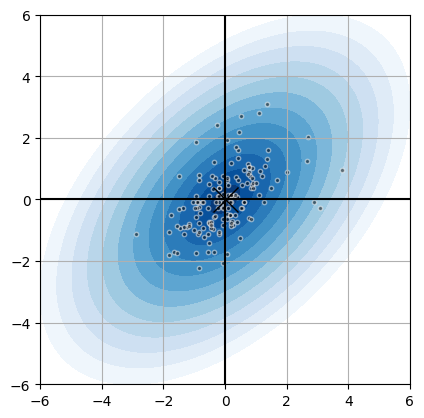

In [96]:
#当前代码块内执行玩所有的绘图配置后,jupyter渲染图片
fig,ax = plt.subplots()

plt.contourf(xx1,xx2,mahal_dd,
             cmap = 'Blues_r',levels = np.linspace(0,6,13))

plt.scatter(X_scaled[:,0],X_scaled[:,1],
            s = 38,edgecolor = 'w',alpha = 0.5,
            marker = '.',color = 'k')

plt.plot(X_scaled[:,0].mean(),X_scaled[:,1].mean(),
         marker = 'x',color = 'k',markersize = 18)

ax.axvline(x = 0,c = 'k')
ax.axhline(y = 0,c = 'k')
ax.grid('off')
ax.set_aspect('equal',adjustable = 'box')
ax.set_xbound(lower = -6,upper = 6)
ax.set_ybound(lower = -6,upper = 6)

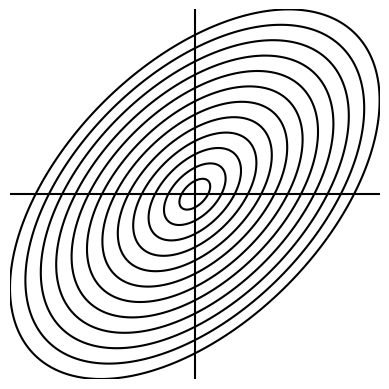

In [98]:
fig,ax = plt.subplots()
plt.contour(xx1,xx2,mahal_dd,
            colors = 'k',levels = np.linspace(0,6,13))
ax.axvline(x = 0,c = 'k')
ax.axhline(y = 0,c = 'k')
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')
ax.set_aspect('equal',adjustable = 'box')
ax.set_xbound(lower = -6,upper = 6)
ax.set_ybound(lower = -6,upper = 6)

In [102]:
from sklearn.decomposition import PCA

#主成分分析
#指定降维后维度为2
n_components = 2
pca = PCA(n_components = 2)

#拟合pca模型
pca.fit(X_scaled)

#获取loading(主成分方向
loadings = pca.components_.T
V = loadings
print(np.round(loadings.T @ loadings))
v1 = V[:,[0]] #第一主成分方向
v2 = V[:,[1]] #第二主成分方向

[[ 1. -0.]
 [-0.  1.]]


In [104]:
pca.explained_variance_

array([1.51796819, 0.49554532])

In [106]:
pca.explained_variance_ratio_

array([0.75389024, 0.24610976])

In [108]:
#自定义绘制向量函数
#输入二维向量和RGB
def draw_vector(vector,RGB):
    #起点再原点,执行了x和y方向的分量
    array = np.array([[0,0,vector[0],vector[1]]],dtype = object)
    #解包
    X,Y,U,V = zip(*array)
    #绘制二维箭头
    plt.quiver(X,Y,U,V,angles = 'xy',#根据角度绘制
               #使用真实坐标比例 #图层优先级1e5表示最上层
                scale_units = 'xy',scale=1,color=RGB,zorder = 1e5)

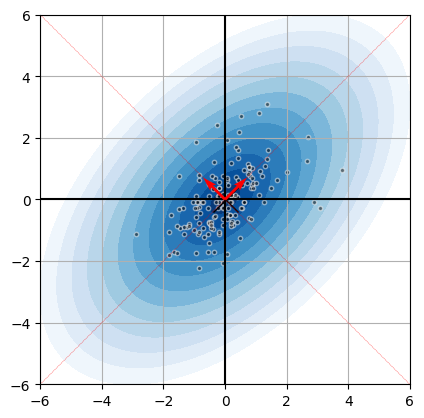

In [110]:
fig,ax = plt.subplots()
plt.contourf(xx1,xx2,mahal_dd,
             cmap = 'Blues_r',levels = np.linspace(0,6,13))
plt.scatter(X_scaled[:,0],X_scaled[:,1],
            s = 38,edgecolor = 'w',alpha = 0.5,
            marker = '.',color = 'k')
#plot可以绘制点,如果仅仅传达一个点,就绘制一个点
plt.plot(X_scaled[:,0].mean(),X_scaled[:,1].mean(),
         marker = 'x',color = 'k',markersize = 18)
#可视化两个主成分方向
draw_vector(v1,'r')
draw_vector(v2,'r')

#第二个y值都是x 乘以的斜率
ax.plot(x1_array,x1_array*v1[1]/v1[0],'r',
        lw = 0.25,ls = 'dashed')
ax.plot(x1_array,x1_array*v2[1]/v2[0],'r',
        #l是line w是宽度 s是style dashed表示虚线
        lw = 0.25,ls = 'dashed')

ax.axvline(x = 0,c = 'k');ax.axhline(y = 0,c = 'k')
ax.grid('off')
ax.set_aspect('equal',adjustable = 'box')
ax.set_xbound(lower = -6,upper = 6,);ax.set_ybound(lower = -6,upper = 6)

In [112]:
#完成投影
proj1 = v1@v1.T
z1_2D = X_scaled@proj1

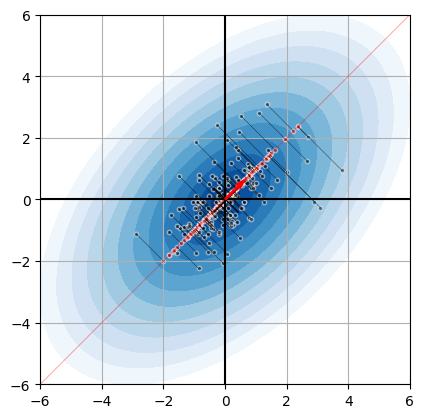

In [114]:
fig,ax = plt.subplots()

plt.contourf(xx1,xx2,mahal_dd,
             cmap = 'Blues_r',levels = np.linspace(0,6,13))
plt.scatter(X_scaled[:,0],X_scaled[:,1],
            s = 38,edgecolor = 'w',alpha = 0.5,
            marker = '.',color = 'k')
plt.plot(X_scaled[:,0].mean(),X_scaled[:,1].mean(),
         marker = 'x',color = 'k',markersize = 18)

plt.scatter(z1_2D[:,0],z1_2D[:,1],
            s = 38,edgecolor = 'w',alpha=0.5,
            marker = '.',color = 'r')
plt.plot(([i for (i,j) in z1_2D],[i for (i,j) in X_scaled]),
         ([j for (i,j) in z1_2D],[j for (i,j) in X_scaled]),
         c = 'k',lw = 0.25)

draw_vector(v1,'r')
ax.plot(x1_array,x1_array*v1[1]/v1[0],'r',lw = 0.25)

ax.axvline(x = 0,c = 'k')
ax.axhline(y = 0,c = 'k')
ax.grid('off')
ax.set_aspect('equal',adjustable = 'box')
ax.set_xbound(lower = -6,upper = 6)
ax.set_xbound(lower = -6,upper = 6)

In [116]:
#完成投影
proj2 = v2@v2.T
z2_2D = X_scaled@proj2

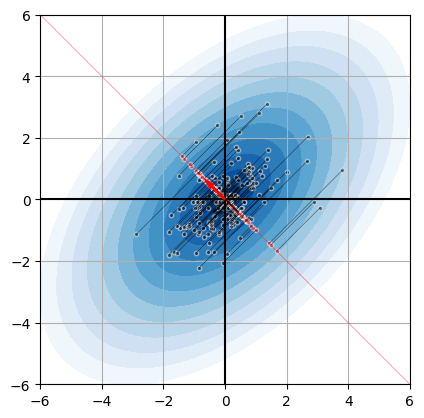

In [118]:
fig,ax = plt.subplots()

plt.contourf(xx1,xx2,mahal_dd,
             cmap = 'Blues_r',levels = np.linspace(0,6,13))
plt.scatter(X_scaled[:,0],X_scaled[:,1],
            s = 38,edgecolor = 'w',alpha = 0.5,
            marker = '.',color = 'k')
plt.plot(X_scaled[:,0].mean(),X_scaled[:,1].mean(),
         marker = 'x',color = 'k',markersize = 18)

plt.scatter(z2_2D[:,0],z2_2D[:,1],
            s = 38,edgecolor = 'w',alpha = 0.5,
            marker = '.',color = 'r')

plt.plot(([i for (i,j) in z2_2D],[i for (i,j) in X_scaled]),
         ([j for (i,j) in z2_2D],[j for (i,j) in X_scaled]),
         c = 'k',lw = 0.25)

draw_vector(v2,'r')
ax.plot(x1_array,x1_array*v2[1]/v2[0],'r',lw = 0.25)

ax.axvline(x = 0, c = 'k')
ax.axhline(y = 0, c = 'k')
ax.grid('off')
ax.set_aspect('equal', adjustable='box')
ax.set_xbound(lower = -6, upper = 6)
ax.set_ybound(lower = -6, upper = 6)

In [120]:
Z = X_scaled @V
COV = EmpiricalCovariance().fit(Z)

In [122]:
mahal_sq_Xc = COV.mahalanobis(xx12)
mahal_sq_dd = mahal_sq_Xc.reshape(xx1.shape)
mahal_dd = np.sqrt(mahal_sq_dd)

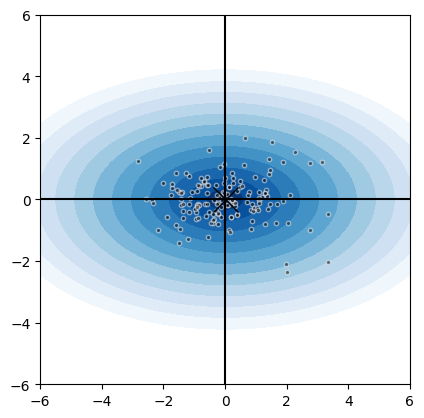

In [126]:
fig,ax = plt.subplots()

plt.contourf(xx1,xx2,mahal_dd,
             cmap='Blues_r',levels = np.linspace(0,6,13))

plt.scatter(Z[:,0],Z[:,1],
           s = 38,edgecolor = 'w',alpha = 0.5,
           marker = '.',color = 'k')

plt.plot(X_scaled[:,0].mean(),X_scaled[:,1].mean(),
         marker = 'x',color = 'k',markersize = 18)

ax.axvline(x = 0,c = 'k')
ax.axhline(y = 0,c = 'k')
ax.grid(0)
ax.set_aspect('equal',adjustable = 'box')
ax.set_xbound(lower = -6,upper = 6)
ax.set_ybound(lower = -6,upper = 6)